# **Week 6 - Building a Baseline Model**

Name: Rhys Brown

## **Import Libraries**

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

pd.set_option("display.width", 120)
print("Libraries have been loaded successfully.")

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score,
)

Libraries have been loaded successfully.


## **Import Dataset**

In [124]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Carisurg_AI_Training_Program/data/yaleemmlc_admissionprediction_triage.csv"

# index_col=0 drops the unnamed export row-number column (see the identifiers note below).
df = pd.read_csv(DATA_PATH, index_col=0)
print(f"Loaded {df.shape[0]:,} ED encounters  x  {df.shape[1]} columns")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 55,121 ED encounters  x  225 columns


In [125]:
df.head()

,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## **Column Organization**

In [126]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

## **Test-train Split**

In [127]:
X_unsplit, y_unsplit = df[FEATURES], df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X_unsplit, y_unsplit, test_size=0.2, stratify = y_unsplit, random_state=42)

## **Scaling of Test and Train Dataset for Dependent Variables**

Logistic Regression requires the features to be scaled before the model is trained on them.

In [128]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # trains standard scaler on X_train
X_test_scaled = scaler.transform(X_test) # uses same standard deviations from X_train to scale X_test

## **Training Machine Learning Models**

In [129]:
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

pred_logreg = logreg.predict(X_test_scaled)

In [130]:
decision_tree = DecisionTreeClassifier(max_depth=10, random_state=42)
decision_tree.fit(X_train, y_train)

pred_decisiontree = decision_tree.predict(X_test)

In [131]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)

pred_dummy = dummy.predict(X_test)

## **Evaluating Accuracy, Precision, Recall and F1-Score of trained Machine Learning Models**

In [132]:
print("Logistic Regression:")
print(classification_report(y_test, pred_logreg, digits=3))
print("\nDecision Tree:")
print(classification_report(y_test, pred_decisiontree, digits=3))
print("\nDummy Classifier:")
print(classification_report(y_test, pred_dummy, digits=3))


Logistic Regression:
              precision    recall  f1-score   support

         1.0      0.444     0.250     0.320        16
         2.0      0.716     0.608     0.658      3585
         3.0      0.660     0.758     0.706      5402
         4.0      0.609     0.587     0.598      1779
         5.0      0.482     0.111     0.181       243

    accuracy                          0.667     11025
   macro avg      0.582     0.463     0.492     11025
weighted avg      0.666     0.667     0.661     11025


Decision Tree:
              precision    recall  f1-score   support

         1.0      0.000     0.000     0.000        16
         2.0      0.742     0.381     0.503      3585
         3.0      0.545     0.888     0.675      5402
         4.0      0.517     0.111     0.182      1779
         5.0      0.000     0.000     0.000       243

    accuracy                          0.577     11025
   macro avg      0.361     0.276     0.272     11025
weighted avg      0.592     0.577     0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Confusion Matricies of trained Machine Learning Models**

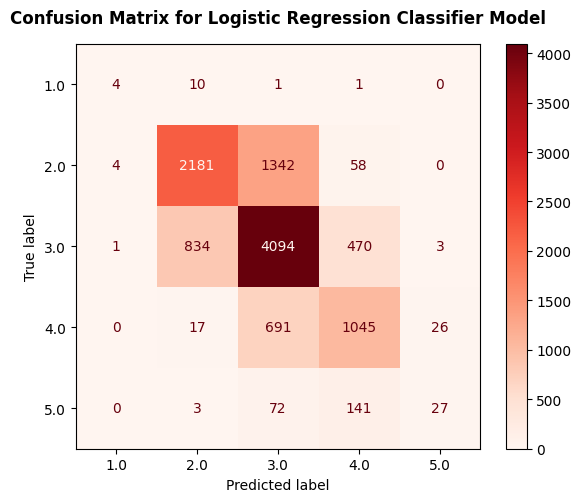

In [133]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, cmap="Reds")
ax.set_title("Confusion Matrix for Logistic Regression Classifier Model", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("cm_logreg.png", dpi=300)
plt.show()

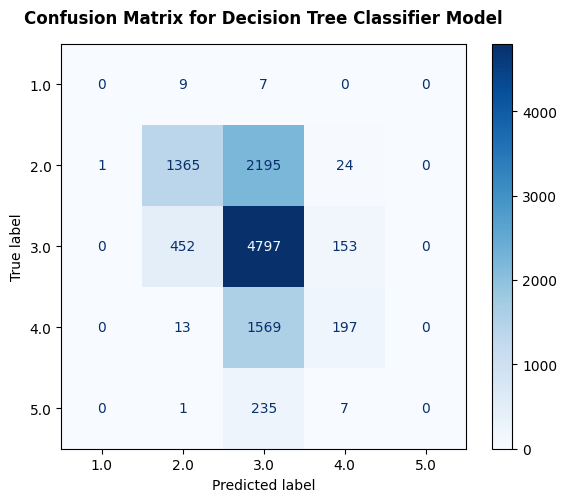

In [134]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = ConfusionMatrixDisplay.from_predictions(y_test, pred_decisiontree, ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix for Decision Tree Classifier Model", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("cm_decisipntree.png", dpi=300)
plt.show()

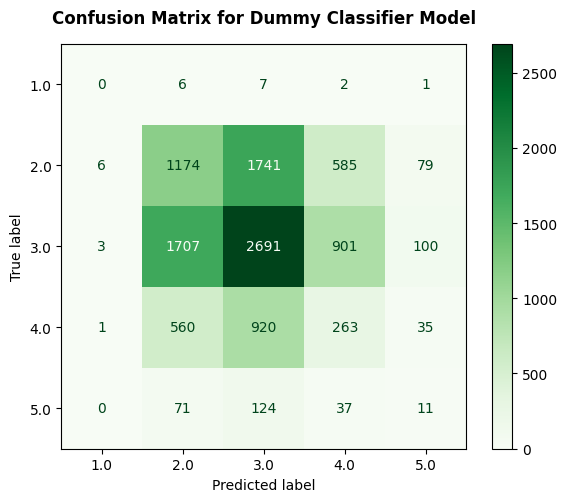

In [135]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = ConfusionMatrixDisplay.from_predictions(y_test, pred_dummy, ax=ax, cmap="Greens")
ax.set_title("Confusion Matrix for Dummy Classifier Model", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("cm_dummy.png", dpi=300)
plt.show()